In [ ]:
!pip install kaggle split-folders gradio -q

import tensorflow as tf
import numpy as np
import os, shutil
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, GlobalAveragePooling2D,
                                      RandomFlip, RandomRotation, RandomZoom,
                                      RandomContrast, Rescaling)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report

print("Setup complete!")

Setup complete!


In [ ]:
from google.colab import files

os.makedirs("/root/.kaggle", exist_ok=True)

print("Upload your kaggle.json file...")
uploaded = files.upload()

shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle configured!")

!kaggle datasets download -d mostafaabla/garbage-classification -p /content/garbage_raw --unzip -q
print("Dataset downloaded!")

Upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle configured!
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
Dataset downloaded!


In [ ]:
raw_root = "/content/garbage_raw"
data_root = os.path.join(raw_root, "garbage_classification")

if not os.path.exists(data_root):
    for root, dirs, _ in os.walk(raw_root):
        if len(dirs) >= 10:
            data_root = root
            break

print("Data root:", data_root)

class_folders = sorted(os.listdir(data_root))
print(f"\nFound {len(class_folders)} classes:")

total_images = 0
for cls in class_folders:
    cls_path = os.path.join(data_root, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total_images += count
        print(f"  {cls:<15} → {count} images")

print(f"\nTotal images: {total_images}")

Data root: /content/garbage_raw/garbage_classification

Found 12 classes:
  battery         → 945 images
  biological      → 985 images
  brown-glass     → 607 images
  cardboard       → 891 images
  clothes         → 5325 images
  green-glass     → 629 images
  metal           → 769 images
  paper           → 1050 images
  plastic         → 865 images
  shoes           → 1977 images
  trash           → 697 images
  white-glass     → 775 images

Total images: 15515


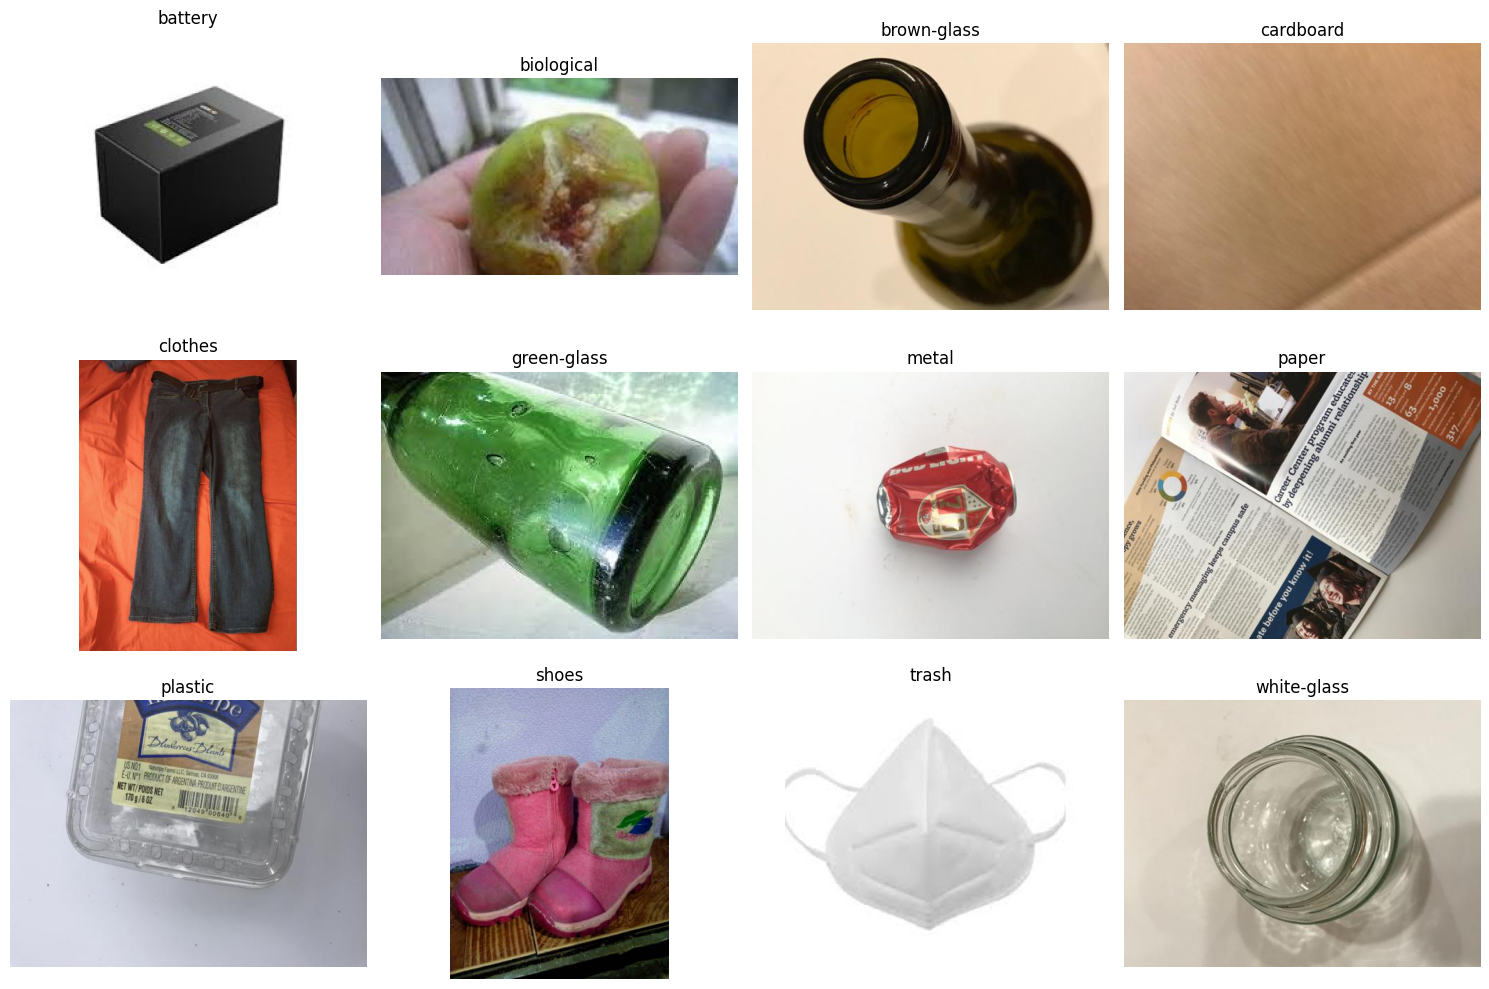

In [ ]:
plt.figure(figsize=(15, 10))
for i, cls in enumerate(class_folders):
    cls_path = os.path.join(data_root, cls)
    sample_img = os.listdir(cls_path)[0]
    img = image.load_img(os.path.join(cls_path, sample_img))
    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import splitfolders

output_dir = "/content/garbage_split"

splitfolders.ratio(
    data_root,
    output=output_dir,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
    move=False
)

print("Dataset split complete!")
for split in ["train", "val", "test"]:
    split_path = os.path.join(output_dir, split)
    total = sum(len(os.listdir(os.path.join(split_path, c))) for c in os.listdir(split_path))
    print(f"  {split}: {total} images")

Copying files: 15515 files [00:03, 4305.69 files/s]

Dataset split complete!
  train: 12409 images
  val: 1545 images
  test: 1561 images


In [ ]:
IMG_SIZE = 160
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{output_dir}/train", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{output_dir}/val", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{output_dir}/test", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Classes ({len(class_names)}):", class_names)

Found 12409 files belonging to 12 classes.
Found 1545 files belonging to 12 classes.
Found 1561 files belonging to 12 classes.
Classes (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [ ]:
norm = Rescaling(1./255)

train_ds_norm = train_ds.map(lambda x, y: (norm(x), y))
val_ds_norm   = val_ds.map(lambda x, y: (norm(x), y))
test_ds_norm  = test_ds.map(lambda x, y: (norm(x), y))

augment = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.1),
    RandomContrast(0.1),
], name="augmentation")

train_ds_aug = train_ds_norm.map(lambda x, y: (augment(x, training=True), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds_aug = train_ds_aug.prefetch(AUTOTUNE)
val_ds_norm  = val_ds_norm.prefetch(AUTOTUNE)
test_ds_norm = test_ds_norm.prefetch(AUTOTUNE)

print("Data pipeline ready!")

Data pipeline ready!


In [ ]:
mobilenet_base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
mobilenet_base.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = mobilenet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs, name="waste_classifier")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "waste_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,364 (10.00 MB)

 Trainable params: 362,380 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_waste_model.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds_aug,
    validation_data=val_ds_norm,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.6413 - loss: 1.1839
Epoch 1: val_accuracy improved from None to 0.90097, saving model to best_waste_model.keras

Epoch 1: finished saving model to best_waste_model.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 188s 473ms/step - accuracy: 0.7463 - loss: 0.8319 - val_accuracy: 0.9010 - val_loss: 0.3366 - learning_rate: 0.0010
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8360 - loss: 0.5235
Epoch 2: val_accuracy improved from 0.90097 to 0.91586, saving model to best_waste_model.keras

Epoch 2: finished saving model to best_waste_model.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 195s 457ms/step - accuracy: 0.8431 - loss: 0.5072 - val_accuracy: 0.9159 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8551 - loss: 0.4531
Epoch 3: val_accuracy did not improve from 0.91586
388/388 ━━━━━━━━━━━━━━━━━━━━ 183s 470ms/step - accuracy: 0.8637 - loss: 0.4356 - val_accurac

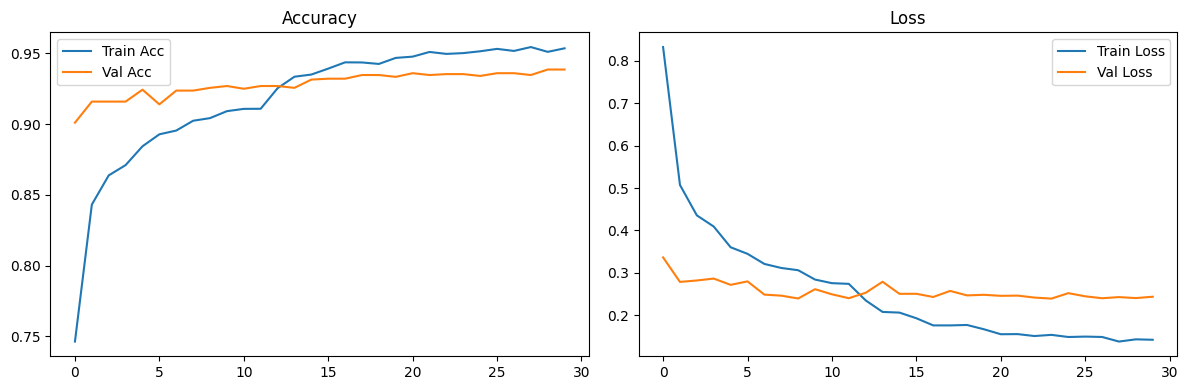

49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 337ms/step - accuracy: 0.9321 - loss: 0.2657

Test Accuracy (frozen base): 93.21%


In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")

plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_ds_norm)
print(f"\nTest Accuracy (frozen base): {test_acc*100:.2f}%")

In [11]:
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_ds_aug,
    validation_data=val_ds_norm,
    epochs=15,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds_norm)
print(f"\nFine-tuned Test Accuracy: {test_acc*100:.2f}%")

model.save("waste_classifier_final.keras")
print("Model saved!")

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8111 - loss: 0.7414
Epoch 1: val_accuracy did not improve from 0.93851
388/388 ━━━━━━━━━━━━━━━━━━━━ 243s 607ms/step - accuracy: 0.8362 - loss: 0.5991 - val_accuracy: 0.9288 - val_loss: 0.2543 - learning_rate: 1.0000e-05
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.8722 - loss: 0.4380
Epoch 2: val_accuracy did not improve from 0.93851
388/388 ━━━━━━━━━━━━━━━━━━━━ 257s 596ms/step - accuracy: 0.8795 - loss: 0.4083 - val_accuracy: 0.9314 - val_loss: 0.2615 - learning_rate: 1.0000e-05
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.8904 - loss: 0.3481
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.93851
388/388 ━━━━━━━━━━━━━━━━━━━━ 237s 609ms/step - accuracy: 0.8929 - loss: 0.3426 - val_accuracy: 0.9366 - val_loss: 0.2442 - learning_rate: 1.0000e-05
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - acc

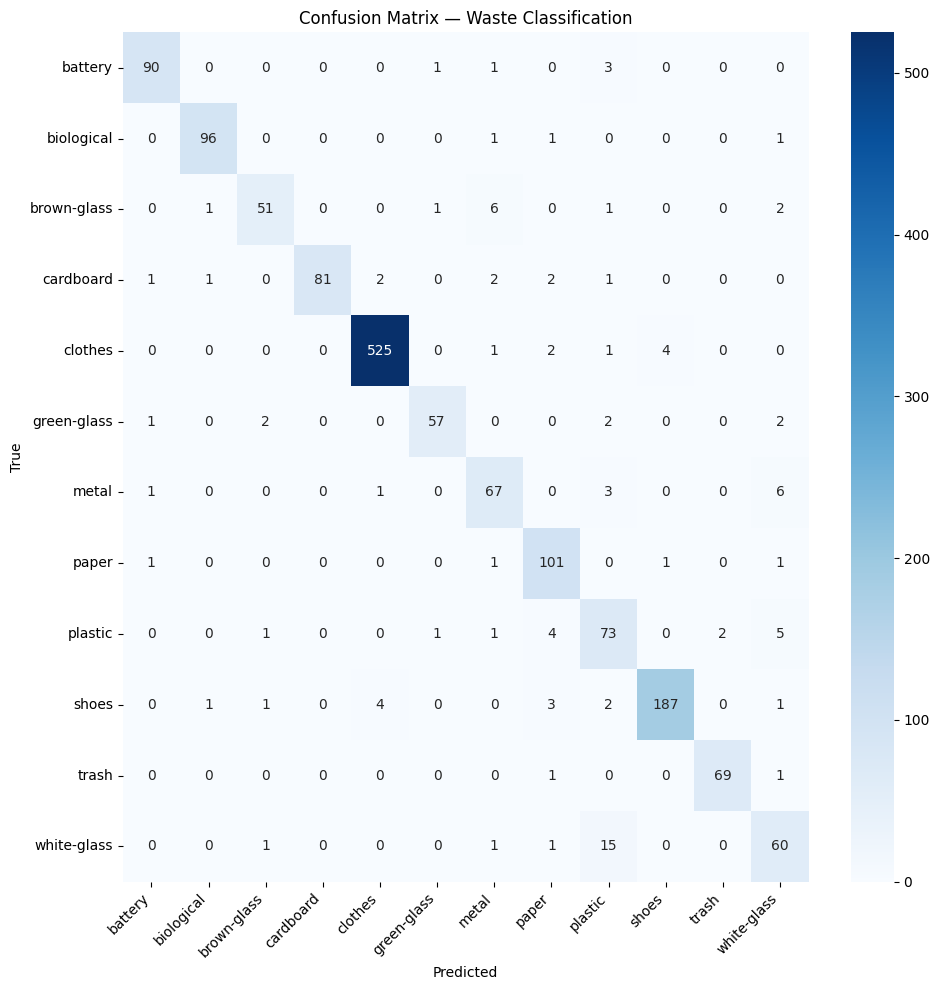


Classification Report:
              precision    recall  f1-score   support

     battery       0.96      0.95      0.95        95
  biological       0.97      0.97      0.97        99
 brown-glass       0.91      0.82      0.86        62
   cardboard       1.00      0.90      0.95        90
     clothes       0.99      0.98      0.99       533
 green-glass       0.95      0.89      0.92        64
       metal       0.83      0.86      0.84        78
       paper       0.88      0.96      0.92       105
     plastic       0.72      0.84      0.78        87
       shoes       0.97      0.94      0.96       199
       trash       0.97      0.97      0.97        71
 white-glass       0.76      0.77      0.76        78

    accuracy                           0.93      1561
   macro avg       0.91      0.90      0.91      1561
weighted avg       0.94      0.93      0.93      1561



In [13]:
y_true, y_pred = [], []
for images, labels in test_ds_norm:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.title("Confusion Matrix — Waste Classification")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Upload a waste image...


Saving test_image2.webp to test_image2.webp
Saving test_image1.webp to test_image1.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


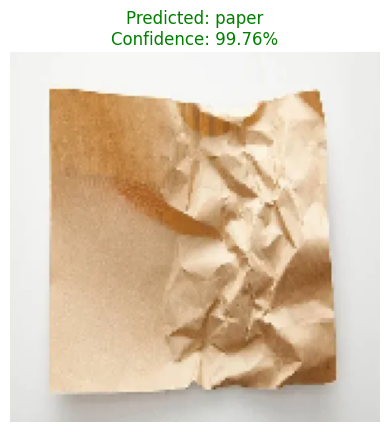


All Probabilities:
  paper           99.76%  ███████████████████████████████████████
  cardboard        0.17%  
  plastic          0.06%  
  metal            0.01%  
  white-glass      0.00%  
  trash            0.00%  
  clothes          0.00%  
  battery          0.00%  
  shoes            0.00%  
  biological       0.00%  
  green-glass      0.00%  
  brown-glass      0.00%  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


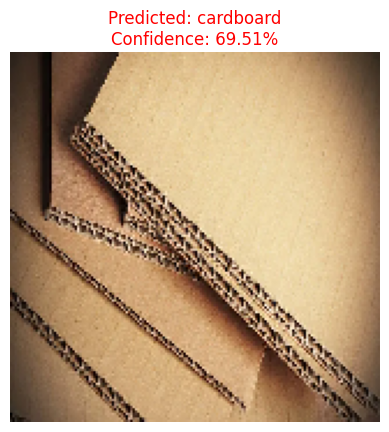


All Probabilities:
  cardboard       69.51%  ███████████████████████████
  clothes         28.05%  ███████████
  paper            2.43%  
  metal            0.00%  
  trash            0.00%  
  plastic          0.00%  
  biological       0.00%  
  shoes            0.00%  
  battery          0.00%  
  white-glass      0.00%  
  brown-glass      0.00%  
  green-glass      0.00%  


In [14]:
from google.colab import files

print("Upload a waste image...")
uploaded = files.upload()

for fname in uploaded.keys():
    img = image.load_img(fname, target_size=(IMG_SIZE, IMG_SIZE))
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, 0)

    preds = model.predict(arr)
    idx = np.argmax(preds[0])
    confidence = preds[0][idx] * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {class_names[idx]}\nConfidence: {confidence:.2f}%",
              color='green' if confidence > 70 else 'red')
    plt.show()

    print("\nAll Probabilities:")
    sorted_idx = np.argsort(preds[0])[::-1]
    for i in sorted_idx:
        bar = "█" * int(preds[0][i] * 40)
        print(f"  {class_names[i]:<15} {preds[0][i]*100:5.2f}%  {bar}")

In [15]:
import gradio as gr

def predict_waste(img):
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img_resized) / 255.0
    arr = np.expand_dims(arr, 0)
    preds = model.predict(arr)[0]
    return {class_names[i]: float(preds[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict_waste,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="♻️ Smart Waste Classifier",
    description="Upload an image of waste and the model will classify it into one of 12 categories: battery, biological, brown-glass, cardboard, clothes, green-glass, metal, paper, plastic, shoes, trash, white-glass."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa3069a0cb202391d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
